# 读取数据

In [14]:
import pandas as pd
import numpy as np

# 读取CSV文件
data = pd.read_csv('gps_sample.csv', encoding='utf-8-sig')

# 标签生成

In [15]:
# 初始化标签列
data['label'] = 0

# 超速 (gps速度 > 80km/h)
data.loc[data['gps速度'] > 80, 'label'] = 1

# 加速度异常 (加速度 > 1.38 或 < -1.54)
data.loc[(data['加速度'] > 1.38) | (data['加速度'] < -1.54), 'label'] = 2

# 曲折度异常 (曲折度 > 1.5)
data.loc[data['曲折度'] > 1.5, 'label'] = 3

# 查看标签分布
print(data['label'].value_counts())


label
0    428
1     88
3     80
2      8
Name: count, dtype: int64


# 时间序列分段

In [16]:
import numpy as np

# 选择特征
features = ['gps速度', '加速度', '曲折度']

# 定义时间窗口大小
window_size = 10

# 创建时间序列窗口
X = []
y = []
for i in range(window_size, len(data)):
    X.append(data[features].iloc[i-window_size:i].values)
    y.append(data['label'].iloc[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)  # 应为 (样本数, window_size, 特征数)
print("y shape:", y.shape)

X shape: (594, 10, 3)
y shape: (594,)


# 数据标准化

In [17]:
from sklearn.preprocessing import StandardScaler

# 重塑数据以适应标准化
X_reshaped = X.reshape(-1, X.shape[-1])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(X.shape)

print("X_scaled shape:", X_scaled.shape)


X_scaled shape: (594, 10, 3)


# 数据集划分

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (475, 10, 3)
Testing set shape: (119, 10, 3)


# 构建CNN-LSTM模型
使用tensorflow或keras构建CNN-LSTM混合模型。CNN用于提取局部特征，LSTM用于捕捉时间序列依赖。

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 构建CNN-LSTM模型
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, len(features))),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=False),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4类：正常(0), 超速(1), 加速度异常(2), 曲折度异常(3)
])

# 编译模型
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 打印模型结构
model.summary()


c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 8, 64)          │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,844 (93.14 KB)

 Trainable params: 23,844 (93.14 KB)

 Non-trainable params: 0 (0.00 B)

# 训练模型

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4060 - loss: 1.3206 - val_accuracy: 0.7158 - val_loss: 1.0381
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7387 - loss: 0.9914 - val_accuracy: 0.7158 - val_loss: 0.8336
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6976 - loss: 0.8608 - val_accuracy: 0.7368 - val_loss: 0.7556
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7285 - loss: 0.7425 - val_accuracy: 0.7368 - val_loss: 0.7096
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7755 - loss: 0.7059 - val_accuracy: 0.7368 - val_loss: 0.6715
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7279 - loss: 0.7203 - val_accuracy: 0.7474 - val_loss: 0.6443
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7342 - loss: 0.6719 - val_accuracy: 0.7368 - val_loss: 0.6332
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7298 - loss: 0.6563 - val_accuracy: 0.7579 - val_loss

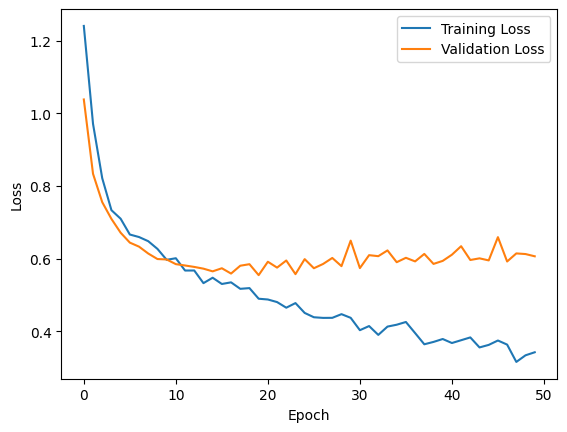

In [20]:
# 训练模型
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# 绘制训练和验证损失
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 评估模型

In [21]:
# 评估模型
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# 预测测试集
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 打印分类报告
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_classes))


Test Accuracy: 0.8151
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
              precision    recall  f1-score   support

           0       0.85      0.90      0.88        84
           1       0.53      0.56      0.54        18
           2       0.00      0.00      0.00         2
           3       1.00      0.73      0.85        15

    accuracy                           0.82       119
   macro avg       0.60      0.55      0.57       119
weighted avg       0.81      0.82      0.81       119



c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

# 结果分析与可视化

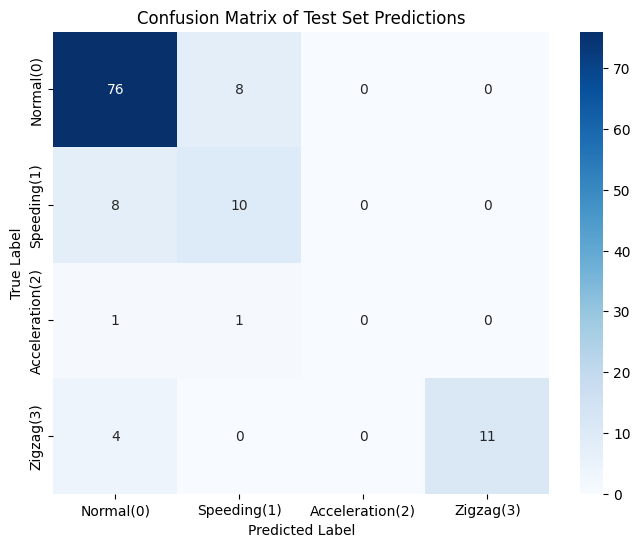

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 假设 y_test 是测试集的真实标签，y_pred_classes 是预测标签
# y_pred_classes 是通过 np.argmax(model.predict(X_test), axis=1) 得到的
cm = confusion_matrix(y_test, y_pred_classes)

# 绘制混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal(0)', 'Speeding(1)', 'Acceleration(2)', 'Zigzag(3)'],
            yticklabels=['Normal(0)', 'Speeding(1)', 'Acceleration(2)', 'Zigzag(3)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Test Set Predictions')
plt.show()


c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Mth13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

<Figure size 1000x600 with 0 Axes>

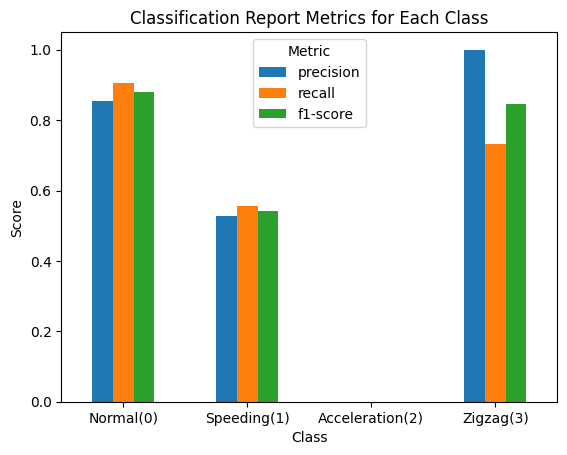

In [23]:
from sklearn.metrics import classification_report
import pandas as pd

# 获取分类报告
report = classification_report(y_test, y_pred_classes, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# 绘制精确率、召回率和F1分数的柱状图
plt.figure(figsize=(10, 6))
report_df[['precision', 'recall', 'f1-score']].iloc[:-3].plot(kind='bar')
plt.title('Classification Report Metrics for Each Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(ticks=range(4), labels=['Normal(0)', 'Speeding(1)', 'Acceleration(2)', 'Zigzag(3)'], rotation=0)
plt.legend(title='Metric')
plt.show()


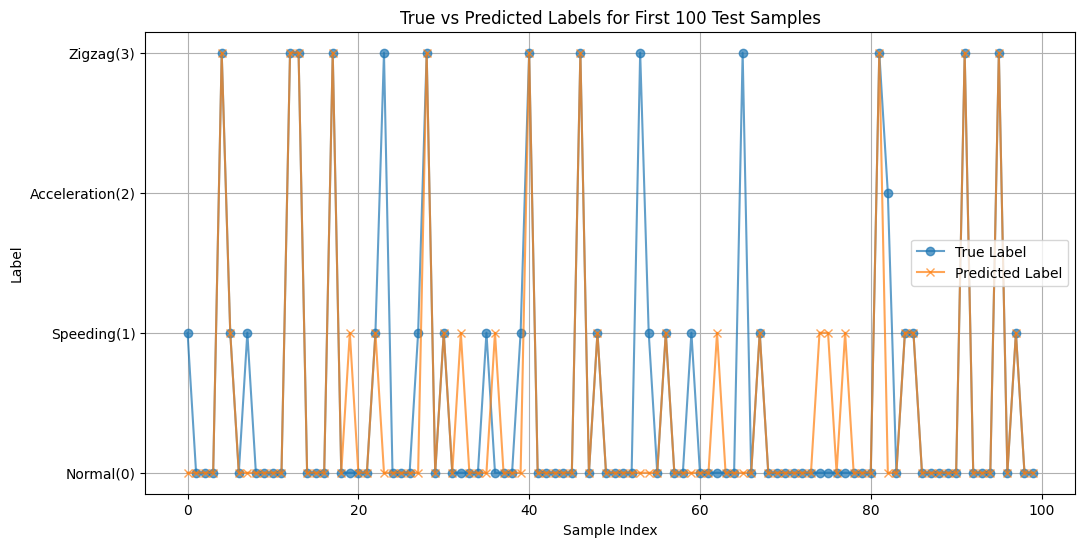

In [24]:
# 假设测试集的索引是连续的，绘制前100个样本的真实值与预测值对比
plt.figure(figsize=(12, 6))
plt.plot(range(100), y_test[:100], label='True Label', marker='o', alpha=0.7)
plt.plot(range(100), y_pred_classes[:100], label='Predicted Label', marker='x', alpha=0.7)
plt.title('True vs Predicted Labels for First 100 Test Samples')
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.yticks([0, 1, 2, 3], ['Normal(0)', 'Speeding(1)', 'Acceleration(2)', 'Zigzag(3)'])
plt.legend()
plt.grid(True)
plt.show()
